<a href="https://colab.research.google.com/github/danielruizm16/ComputationalMethods_2026_I/blob/main/Interpolación/Interpolación.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Interpolación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.interpolate import interp1d,lagrange, CubicHermiteSpline, KroghInterpolator, CubicSpline

# 1.

Usar la porción de la tabla de vapor dada para $\mathrm{H_2O}$ sobrecalentado a 200 MPa para:

- Encontrar la entropía correspondiente $s$ para un volumen específico $v$ de 0.108 $m^3/kg$ mediante interpolación lineal.
- Encontrar la misma entropía correspondiente usando interpolación cuadrática (polinomio de Lagrange).
- Encontrar el volumen correspondiente a una entropía de 6.6 usando interpolación inversa.

```python
v = np.array([0.10377, 0.11144, 0.1254]) # Datos de volumen específico (m³/kg)
s = np.array([6.4147, 6.5453, 6.7664])   # Datos de entropía (kJ/kg·K)
```


In [2]:
# Datos dados
v = np.array([0.10377, 0.11144, 0.1254])  # Datos de volumen específico (m³/kg)
s = np.array([6.4147, 6.5453, 6.7664])    # Datos de entropía (kJ/kg·K)

In [3]:
# Valores objetivo
v_target = 0.108  # m³/kg
s_target = 6.6    # kJ/kg·K

In [4]:
def linear_interpolation(xp, yp, x_interp):
    """
    Realiza interpolación lineal para estimar el valor de y en un punto x dado,
    a partir de un conjunto de puntos conocidos (xp, yp).

    Parámetros:
    -----------
    xp : array_like
        Arreglo de valores conocidos de x (debe estar ordenado de forma ascendente).
    yp : array_like
        Arreglo de valores conocidos de y correspondientes a los valores en xp.
        Debe tener la misma longitud que xp.
    x_interp : float
        Valor de x donde se desea calcular el valor interpolado.

    Retorna:
    --------
    float or None
        - El valor interpolado de y correspondiente a x_interp.
        - None si x_interp está fuera del rango cubierto por xp.

    Proceso:
    --------
    1. Encuentra el intervalo [xp[i], xp[i+1]] que contiene a x_interp.
    2. Aplica la fórmula de interpolación lineal:
       y = yp[i] + (yp[i+1] - yp[i]) * (x - xp[i]) / (xp[i+1] - xp[i])
    3. Si x_interp está fuera del rango de xp, retorna None.
    """
    # Verificación básica de los datos
    if len(xp) != len(yp):
        raise ValueError("xp y yp deben tener la misma longitud")
    if len(xp) < 2:
        raise ValueError("Se necesitan al menos 2 puntos para interpolar")

    # Buscar el intervalo apropiado
    for i in range(len(xp)-1):
        if xp[i] <= x_interp <= xp[i+1]:
            # Calcular la pendiente del segmento
            slope = (yp[i+1] - yp[i]) / (xp[i+1] - xp[i])
            return yp[i] + slope * (x_interp - xp[i])

    # Si x_interp está fuera del rango
    return None


In [5]:
s_linear = linear_interpolation(v, s,v_target)
print(f"Entropía s para v = {v_target} m³/kg usando interpolación lineal: s = {s_linear:.4f} kJ/kg·K")

Entropía s para v = 0.108 m³/kg usando interpolación lineal: s = 6.4867 kJ/kg·K


## Interpolación lineal usando numpy

In [6]:
s_linear_numpy = np.interp(v_target, v, s)
print(f"Entropía s para v = {v_target} m³/kg usando interpolación lineal con numpy: s = {s_linear_numpy:.4f} kJ/kg·K")

Entropía s para v = 0.108 m³/kg usando interpolación lineal con numpy: s = 6.4867 kJ/kg·K


## Interpolación lineal usando scipy

In [7]:
linear_interp_scipy=interp1d(v,s,kind='linear')
s_linear_scipy =linear_interp_scipy(v_target)
print(f"Entropía s para v = {v_target} m³/kg usando interpolación lineal con scipy: s = {s_linear_scipy:.4f} kJ/kg·K")

Entropía s para v = 0.108 m³/kg usando interpolación lineal con scipy: s = 6.4867 kJ/kg·K


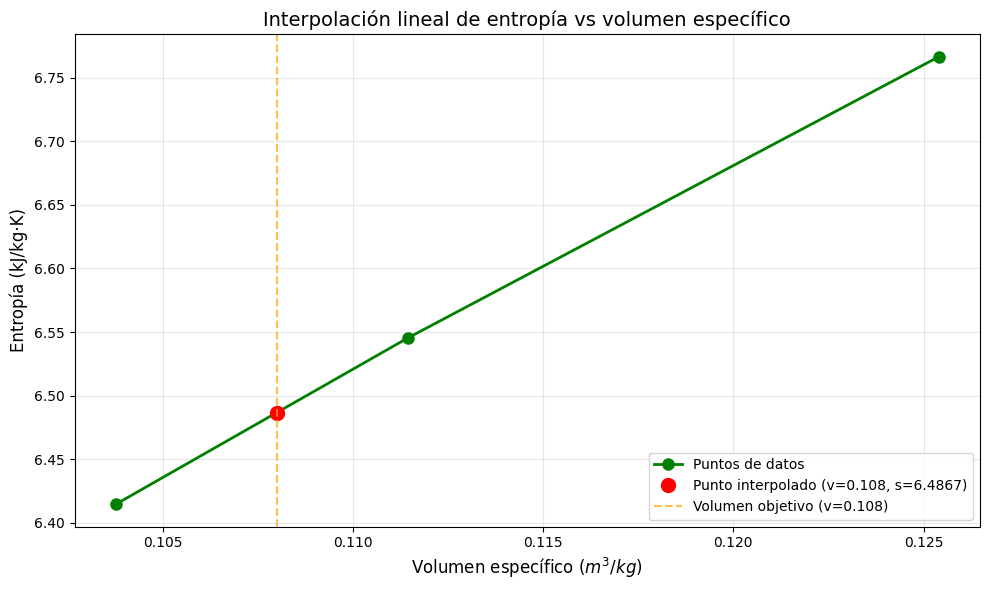

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(v, s, 'go-', linewidth=2, markersize=8, label='Puntos de datos')
plt.plot(v_target, s_linear, 'ro', markersize=10, label=f'Punto interpolado (v={v_target}, s={s_linear:.4f})')
plt.axvline(x=v_target, color='orange', linestyle='--', alpha=0.7, label=f'Volumen objetivo (v={v_target})')
plt.xlabel(r'Volumen específico ($m^3/kg$)', fontsize=12)
plt.ylabel('Entropía (kJ/kg·K)', fontsize=12)
plt.title('Interpolación lineal de entropía vs volumen específico', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
def quadratic_interpolation(x_data, y_data, x):
    """
    Realiza interpolación cuadrática usando el método del polinomio de Lagrange con tres puntos de datos.

    Parámetros:
    -----------
    x_data : array_like
        Arreglo con las tres coordenadas x de los puntos conocidos [x0, x1, x2].
    y_data : array_like
        Arreglo con las tres coordenadas y de los puntos conocidos [y0, y1, y2].
    x : float
        Valor de x en el cual se evalúa el polinomio interpolante.

    Retorna:
    --------
    float
        Valor interpolado de y en el x dado.

    Notas:
    ------
    - Requiere exactamente 3 puntos de datos (interpolación cuadrática).
    """

    result = 0
    for i in range(3):
        term = y_data[i]
        for j in range(3):
            if i != j:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += term
    return result


In [10]:
s_quadratic = quadratic_interpolation(v, s, v_target)
print(f"Entropía s para v = {v_target} m³/kg usando interpolación cuadrática: s = {s_quadratic:.4f} kJ/kg·K")


Entropía s para v = 0.108 m³/kg usando interpolación cuadrática: s = 6.4875 kJ/kg·K


In [11]:
v_inverse = quadratic_interpolation(s, v, s_target)
print(f"Volumen v para s = {s_target}: v = {v_inverse:.5f} m³/kg")

Volumen v para s = 6.6: v = 0.11478 m³/kg


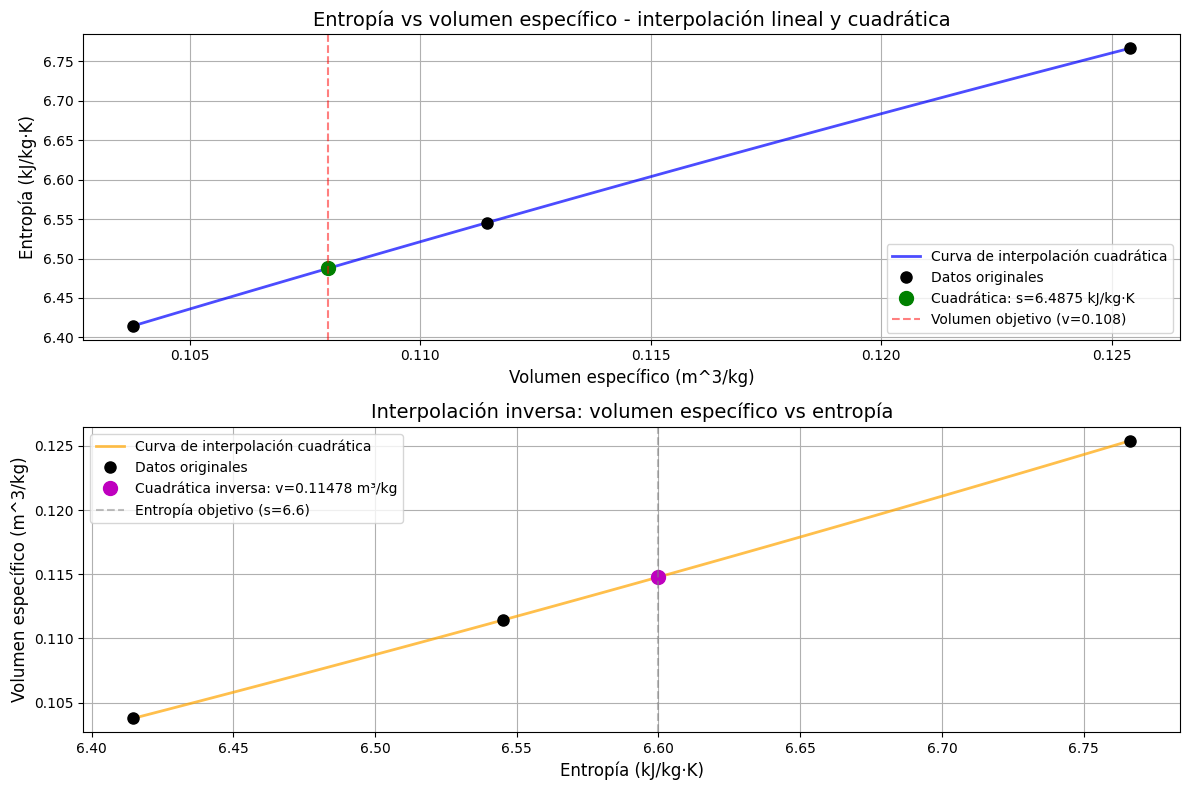

In [12]:
# Crear gráfica completa
plt.figure(figsize=(12, 8))

# Generar curvas suaves para la visualización
v_vals = np.linspace(v.min(), v.max(), 100)
s_quad_vals = [quadratic_interpolation(v, s, x) for x in v_vals]

# Gráfica 1: entropía vs volumen
plt.subplot(2, 1, 1)

# Graficar curva cuadrática suave
plt.plot(v_vals, s_quad_vals, 'b-', alpha=0.7, linewidth=2, label='Curva de interpolación cuadrática')

# Graficar puntos de datos originales
plt.plot(v, s, 'ko', markersize=8, label='Datos originales')

# Graficar resultado de interpolación cuadrática
plt.plot(v_target, s_quadratic, 'go', markersize=10,
         label=f'Cuadrática: s={s_quadratic:.4f} kJ/kg·K')

# Añadir líneas de referencia
plt.axvline(x=v_target, color='red', linestyle='--', alpha=0.5, label=f'Volumen objetivo (v={v_target})')

# Personalizar subgráfica 1
plt.xlabel(r'Volumen específico (m^3/kg)', fontsize=12)
plt.ylabel('Entropía (kJ/kg·K)', fontsize=12)
plt.title('Entropía vs volumen específico - interpolación lineal y cuadrática', fontsize=14)
plt.grid()
plt.legend()

# Gráfica 2: volumen vs entropía (interpolación inversa)
plt.subplot(2, 1, 2)

# Generar curva suave para la relación inversa
s_vals = np.linspace(s.min(), s.max(), 100)
v_quad_vals = [quadratic_interpolation(s, v, x) for x in s_vals]

# Graficar curva cuadrática suave
plt.plot(s_vals, v_quad_vals, color='orange', alpha=0.7, linewidth=2, label='Curva de interpolación cuadrática')

# Graficar puntos de datos originales
plt.plot(s, v, 'ko', markersize=8, label='Datos originales')

# Graficar resultado de interpolación inversa
plt.plot(s_target, v_inverse, 'mo', markersize=10,
         label=f'Cuadrática inversa: v={v_inverse:.5f} m³/kg')

plt.axvline(x=s_target, color='gray', linestyle='--', alpha=0.5, label=f'Entropía objetivo (s={s_target})')

# Personalizar subgráfica 2
plt.xlabel('Entropía (kJ/kg·K)', fontsize=12)
plt.ylabel(r'Volumen específico (m^3/kg)', fontsize=12)
plt.title('Interpolación inversa: volumen específico vs entropía', fontsize=14)
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


# 2.

A partir de un experimento, el coeficiente de conducción de calor $k$ de un material de aluminio varía con la temperatura $T$ como se muestra en la tabla. Derivar el polinomio de interpolación de Lagrange para estimar los valores del coeficiente de conducción de calor en $50^\circ C$ y $250^\circ C$.

```python
T = np.array([-100, 0, 100, 200, 300, 400]) # Temperaturas en °C
k = np.array([215, 202, 206, 215, 228, 249]) # Coeficientes de conducción de calor en W/(m·°C)
```


In [13]:
def lagrange_interpolation(x_data, y_data, x_interp):
    """
    Interpolación de Lagrange para estimar y en x_interp

    Parámetros:
    x_data: arreglo de valores conocidos de x
    y_data: arreglo de valores conocidos de y
    x_interp: valor de x donde se desea interpolar

    Retorna:
    y_interp: valor interpolado en x_interp
    """
    n = len(x_data)
    y_interp = 0.0

    for i in range(n):
        # Calcular el término base de Lagrange L_i(x)
        term = y_data[i]
        for j in range(n):
            if j != i:
                term *= (x_interp - x_data[j]) / (x_data[i] - x_data[j])
        y_interp += term

    return y_interp


In [14]:
# Datos del problema
T = np.array([-100, 0, 100, 200, 300, 400])  # Temperaturas en °C
k = np.array([215, 202, 206, 215, 228, 249])  # Coeficientes en W/(m·°C)

In [15]:
# Puntos a interpolar
T_interp = [50, 250]

In [16]:
# Calcular interpolaciones
results = {}
for temp in T_interp:
    results[temp] = lagrange_interpolation(T, k, temp)

# Mostrar resultados
for temp, k_val in results.items():
    print(f"k({temp}°C) = {k_val:.2f} W/(m·°C)")

k(50°C) = 202.95 W/(m·°C)
k(250°C) = 220.80 W/(m·°C)


In [17]:
# Rango de temperatura para graficar
T_plot = np.linspace(-150, 400, 100)
k_plot = [lagrange_interpolation(T, k, t) for t in T_plot]

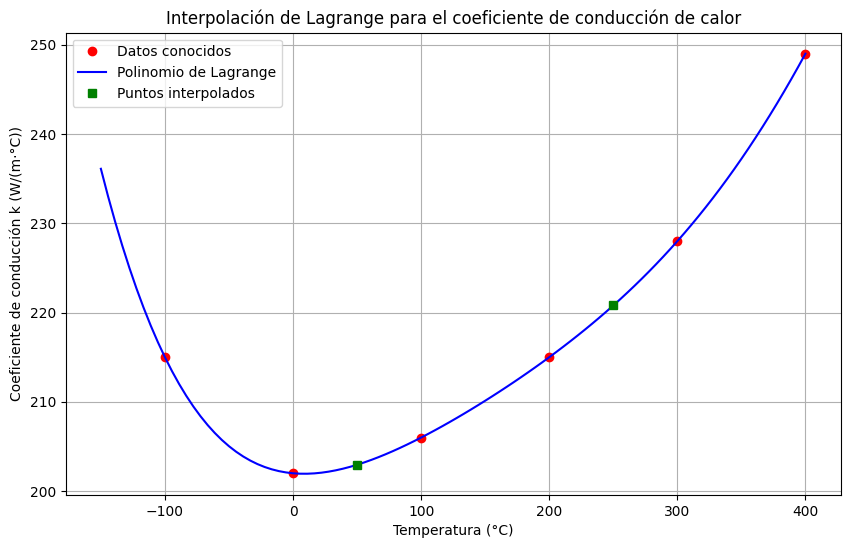

In [18]:
# Puntos originales y puntos interpolados
plt.figure(figsize=(10, 6))
plt.plot(T, k, 'ro', label='Datos conocidos')
plt.plot(T_plot, k_plot, 'b-', label='Polinomio de Lagrange')
plt.plot(T_interp, list(results.values()), 'gs', label='Puntos interpolados')
plt.title('Interpolación de Lagrange para el coeficiente de conducción de calor')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Coeficiente de conducción k (W/(m·°C))')
plt.legend()
plt.grid()
plt.show()


# 3.

La disminución de la temperatura debida al viento (sensación térmica) depende de la velocidad del viento. Un conjunto de datos de temperatura en función de la velocidad del viento se muestra en la siguiente tabla. Usar el método de diferencias divididas de Newton para estimar la temperatura a una velocidad del viento de 35 km/h. Con base en los datos proporcionados, ¿es posible que la temperatura descienda por debajo de -50 °C? Si es posible, encontrar la velocidad del viento que produce dicha temperatura.

```python
wind_speed = np.array([0, 10, 20, 30, 40, 50])  # Velocidad del viento (km/h)
temperature = np.array([-12, -23, -31, -36, -38, -39])  # Temperatura (°C)
```


In [19]:
def newton_interpolation(x_data, y_data, x_interp):
    """
    Polinomio de interpolación de Newton usando diferencias divididas.
    Sigue la fórmula:
    P(x) = f[x0] + f[x0,x1](x-x0) + f[x0,x1,x2](x-x0)(x-x1) + ...

    Parámetros:
    -----------
    x_data : list or array
        Puntos conocidos de x
    y_data : list or array
        Valores conocidos de y
    x_interp : float
        Punto donde se desea evaluar el polinomio

    Retorna:
    --------
    float
        Valor interpolado en x_interp
    """
    n = len(x_data)

    # Calcular diferencias divididas
    def divided_diff(xs, ys):
        """Calcula las diferencias divididas de forma recursiva"""
        if len(xs) == 1:
            return ys[0]
        return (divided_diff(xs[1:], ys[1:]) - divided_diff(xs[:-1], ys[:-1])) / (xs[-1] - xs[0])

    # Evaluar el polinomio usando la fórmula explícita
    result = y_data[0]  # Primer término: f[x0]
    product_term = 1.0

    for i in range(1, n):
        # Construir el producto: (x - x0)(x - x1)...(x - x_{i-1})
        product_term *= (x_interp - x_data[i-1])

        # Obtener el coeficiente de diferencia dividida
        coeff = divided_diff(x_data[0:i+1], y_data[0:i+1])

        # Añadir término: coeficiente × producto
        result += coeff * product_term

    return result


In [20]:
# Datos proporcionados
wind_speed = np.array([0, 10, 20, 30, 40, 50])  # km/h
temperature = np.array([-12, -23, -31, -36, -38, -39])  # °C

# 1. Estimación a 35 km/h
temp_35 = newton_interpolation(wind_speed, temperature, 35)
print(f"Temperatura estimada a 35 km/h: {temp_35:.2f} °C")

Temperatura estimada a 35 km/h: -37.32 °C


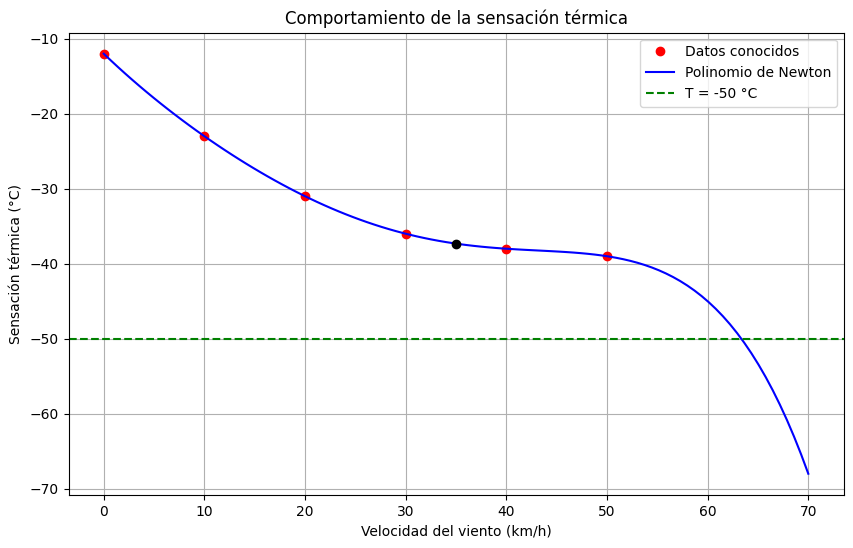

In [21]:
# Rango extendido para visualización
wind_speed_ext = np.linspace(0, 70, 100)
temp_ext = [newton_interpolation(wind_speed, temperature, v) for v in wind_speed_ext]

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(wind_speed, temperature, 'ro', label='Datos conocidos')
plt.plot(wind_speed_ext, temp_ext, 'b-', label='Polinomio de Newton')
plt.plot(35, temp_35, 'ko')
plt.axhline(y=-50, color='g', linestyle='--', label='T = -50 °C')
plt.xlabel('Velocidad del viento (km/h)')
plt.ylabel('Sensación térmica (°C)')
plt.title('Comportamiento de la sensación térmica')
plt.legend()
plt.grid()
plt.show()


In [22]:
from scipy.optimize import newton

# Función objetivo para encontrar la raíz (T(v) + 50 = 0)
def func(v):
    return newton_interpolation(wind_speed, temperature, v) + 50

# Estimación inicial basada en la tendencia
v_guess = 60  # km/h (valor inicial de búsqueda)

critical_speed = newton(func, v_guess)

print(f"\nLa temperatura alcanza -50 °C aproximadamente a {critical_speed:.2f} km/h")

# Verificación
temp_verification = newton_interpolation(wind_speed, temperature, critical_speed)
print(f"Temperatura verificada a {critical_speed:.2f} km/h: {temp_verification:.6f} °C")



La temperatura alcanza -50 °C aproximadamente a 63.35 km/h
Temperatura verificada a 63.35 km/h: -50.000000 °C


# 4.

Los siguientes datos describen la presión (kPa) en función de la altitud desde el nivel del mar según la Atmósfera Estándar de EE. UU.:

```python
altitude = np.array([0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]) # en m
pressure = np.array([101.33, 89.88, 79.50, 70.12, 61.66, 54.05, 47.22, 41.11, 35.65, 30.80, 26.50]) # en kPa
```

Usando tanto un polinomio de Hermite como splines cúbicos, determinar la presión en la cima del monte Everest.


In [23]:
# Datos proporcionados
altitude = np.array([0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]) # in m
pressure = np.array([101.33, 89.88, 79.50, 70.12, 61.66, 54.05, 47.22, 41.11, 35.65, 30.80, 26.50]) # in kPa

# Mount Everest altitude in meters
everest = 8848.86

## Splines cúbicos

In [24]:
# Crear el spline cúbico
cubic_spline = CubicSpline(altitude, pressure, bc_type='natural')

# Evaluar a la altitud del Everest
pressure_spline = cubic_spline(everest)

print(f"Presión en el Everest (splines cúbicos): {pressure_spline:.2f} kPa")


Presión en el Everest (splines cúbicos): 31.49 kPa


## Hermite

In [25]:
def hermite_interpolation(x_points, y_points, derivatives, x_interp):
    """
    Interpolación de Hermite para estimar y en x_interp usando sympy

    Argumentos:
        x_points (list): Lista de puntos x donde se evalúa la función
        y_points (list): Lista de valores f(x) en los puntos
        derivatives (list): Lista de derivadas f'(x) en los puntos
        x_interp (float): valor de x donde se desea interpolar

    Retorna:
        float: valor interpolado en x_interp
    """
    x = sp.symbols('x')
    n = len(x_points)
    H = 0.0

    for i in range(n):
        # Base de Lagrange h_i(x)
        h_i = 1
        for j in range(n):
            if j != i:
                h_i *= (x - x_points[j]) / (x_points[i] - x_points[j])

        # Derivada de h_i en x_i usando sympy
        h_i_prime = sp.diff(h_i, x).subs(x, x_points[i])

        # Términos de Hermite
        term1 = (h_i**2) * (1 - 2 * (x - x_points[i]) * h_i_prime) * y_points[i]
        term2 = (h_i**2) * (x - x_points[i]) * derivatives[i]

        H += term1 + term2

    # Evaluar en el punto de interpolación
    return H.subs(x, x_interp)


In [26]:
# Calcular derivadas aproximadas usando diferencias finitas
derivatives = np.gradient(pressure, altitude)

# Evaluar a la altitud del Everest
pressure_hermite = hermite_interpolation(altitude, pressure, derivatives, everest)

print(f"Presión en el Everest (Hermite): {pressure_hermite:.2f} kPa")


Presión en el Everest (Hermite): 31.43 kPa


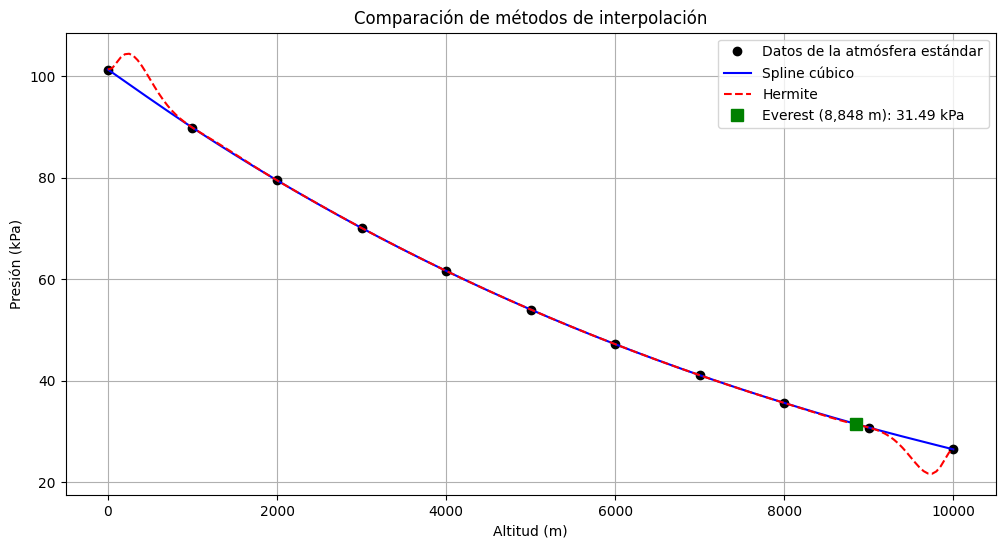

In [27]:
# Crear un rango para graficar
altitude_plot = np.linspace(0, 10000, 200)

# Gráfica comparativa
plt.figure(figsize=(12, 6))
plt.plot(altitude, pressure, 'ko', label='Datos de la atmósfera estándar')
plt.plot(altitude_plot, cubic_spline(altitude_plot), 'b-', label='Spline cúbico')
plt.plot(altitude_plot, np.array([hermite_interpolation(altitude, pressure, derivatives, x) for x in altitude_plot]), 'r--', label='Hermite')
plt.plot(everest, pressure_spline, 'gs', markersize=8,
         label=f'Everest (8,848 m): {pressure_spline:.2f} kPa')
plt.xlabel('Altitud (m)')
plt.ylabel('Presión (kPa)')
plt.title('Comparación de métodos de interpolación')
plt.legend()
plt.grid()
plt.show()


# 5.

En física nuclear, la sección eficaz de dispersión se calcula a partir de experimentos de colisión. Se sabe por teoría que la sección eficaz está descrita por la fórmula de Breit-Wigner,

$$\sigma(E)=\frac{\sigma_0}{(E-E_r)^2+\frac{\Gamma^2}{4}}$$

donde $E$ es la energía y $E_r,\sigma_0, \Gamma$ son parámetros a ajustar; el valor predicho es $(E_r,\Gamma) = (78, 55)$ MeV; además, $\sigma_0$ puede calcularse a partir de la fórmula sustituyendo cualquier par de puntos de la tabla.

A partir de los valores de energía:

```python
Energy = np.array([0, 25, 50, 75, 100, 125, 150, 175, 200])
sigma_exp = np.array([10.6, 16.0, 45.0, 83.5, 52.8, 19.9, 10.8, 8.25, 4.7])
```

- Calcular los polinomios de Lagrange, Newton y Hermite.
- Crear una gráfica de los polinomios junto con la función.
- Finalmente, a partir de la diferencia $|f(x) - P_n(x)|$, calcular el error asociado a cada uno. ¿Cuál será el mejor?


In [28]:
# Datos dados
Energy = np.array([0, 25, 50, 75, 100, 125, 150, 175, 200])
sigma_exp = np.array([10.6, 16.0, 45.0, 83.5, 52.8, 19.9, 10.8, 8.25, 4.7])

# Parámetros de la fórmula de Breit-Wigner
Er, Gamma = 78, 55  # MeV

# Calcular sigma0 usando el punto (75, 83.5) como se sugiere
E_point, sigma_point = 75, 83.5
sigma0 = sigma_point * ((E_point - Er)**2 + Gamma**2/4)


In [29]:
def breit_wigner(E):
    return sigma0 / ((E - Er)**2 + Gamma**2/4)

In [30]:
# Derivada de la fórmula de Breit-Wigner
def breit_wigner_derivative(E):
    return -2*sigma0*(E - Er) / ((E - Er)**2 + Gamma**2/4)**2

# Calcular derivadas exactas en los puntos de datos
exact_derivatives = breit_wigner_derivative(Energy)

In [31]:
# 1. Interpolación de Lagrange usando scipy
lagrange_poly = lagrange(Energy, sigma_exp)

In [32]:
# 2. Interpolación de Hermite con derivadas exactas (función por tramos) 
exact_derivatives = breit_wigner_derivative(Energy)
hermite_poly_pw = CubicHermiteSpline(Energy, sigma_exp, exact_derivatives)

In [33]:
# Interpolación de Hermite con derivadas exactas (polinomio de Hermite basado en diferencias divididas) 
yi_krogh = np.column_stack([sigma_exp, exact_derivatives])
hermite_poly=KroghInterpolator(Energy, yi_krogh)

In [34]:
# 3. Interpolación de Krogh (interpolación de Newton)
newton_poly = KroghInterpolator(Energy, sigma_exp)

In [35]:
# Puntos de evaluación (malla fina entre puntos de datos)
x_fine = np.linspace(0, 200, 500)

In [36]:
# Calcular la función real y las interpolaciones en una malla fina
true_vals = breit_wigner(x_fine)
lagrange_vals = lagrange_poly(x_fine)
hermite_vals = hermite_poly_pw(x_fine)
newton_vals = newton_poly(x_fine)


In [37]:
# Calcular los errores |f(x) - P(x)| en una malla fina
lagrange_errors = np.abs(true_vals - lagrange_vals)
hermite_errors = np.abs(true_vals - hermite_vals)
barycentric_errors = np.abs(true_vals - newton_vals)

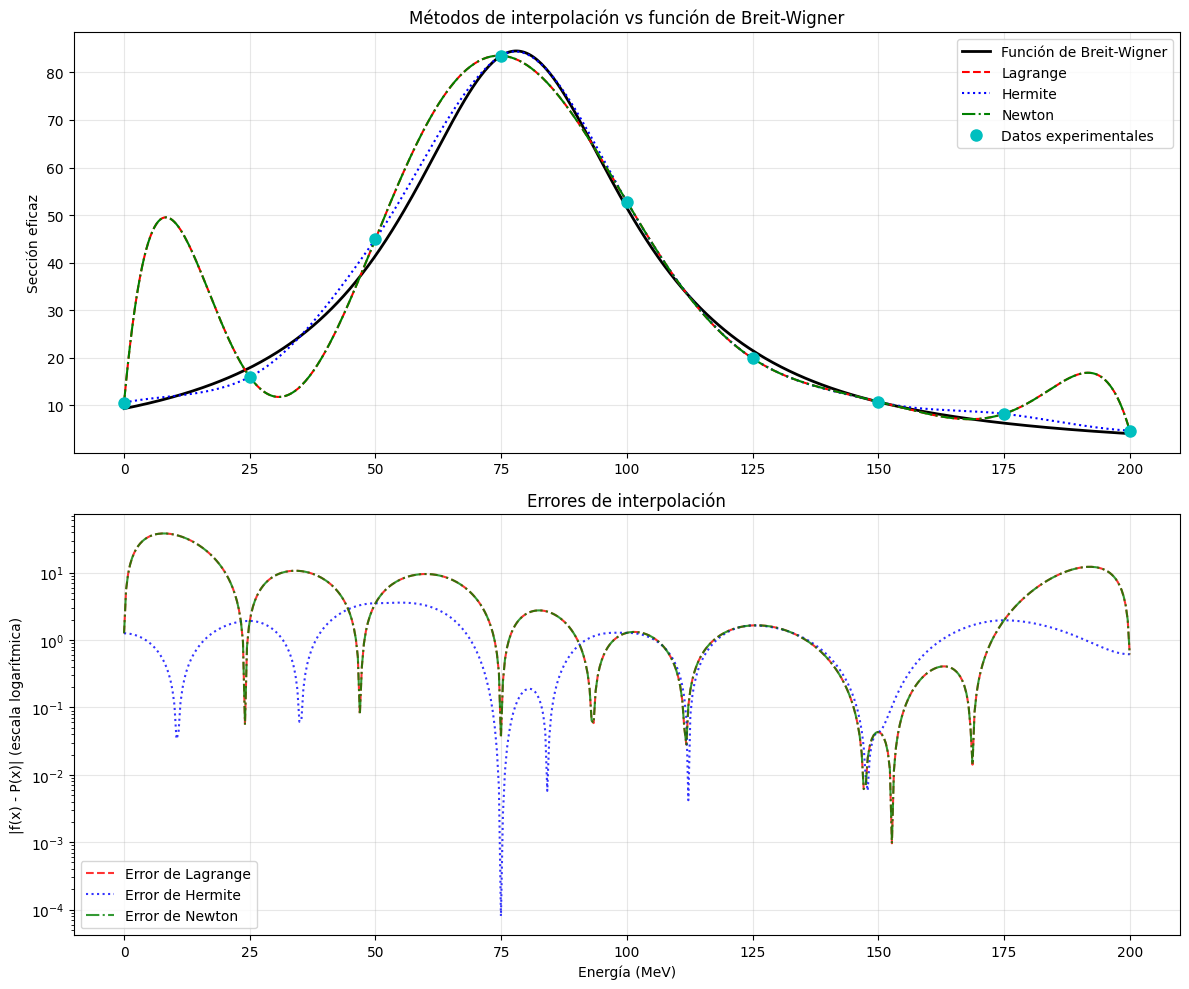

In [38]:
# Gráfica 1: interpolaciones vs función real
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(x_fine, true_vals, 'k-', linewidth=2, label='Función de Breit-Wigner')
plt.plot(x_fine, lagrange_vals, 'r--', linewidth=1.5, label='Lagrange')
plt.plot(x_fine, hermite_vals, 'b:', linewidth=1.5, label='Hermite')
plt.plot(x_fine, newton_vals, 'g-.', linewidth=1.5, label='Newton')
plt.plot(Energy, sigma_exp, 'co', markersize=8, label='Datos experimentales')
plt.ylabel('Sección eficaz')
plt.title('Métodos de interpolación vs función de Breit-Wigner')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: errores en malla fina
plt.subplot(2, 1, 2)
plt.semilogy(x_fine, lagrange_errors, 'r--', label='Error de Lagrange', alpha=0.8)
plt.semilogy(x_fine, hermite_errors, 'b:', label='Error de Hermite', alpha=0.8)
plt.semilogy(x_fine, barycentric_errors, 'g-.', label='Error de Newton', alpha=0.8)
plt.xlabel('Energía (MeV)')
plt.ylabel('|f(x) - P(x)| (escala logarítmica)')
plt.title('Errores de interpolación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
